# Data Cleaning and EDA

This notebook has been reworked to be reproducible and useful for downstream modeling.

Goals:
- Load data using repo-relative paths
- Perform a clear data audit before cleaning
- Clean the data with explicit rules
- Create features aligned with the fraud detection pipeline
- Run EDA focused on variables that are useful for modeling

## 1. Setup

In [36]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Load Data

This notebook uses relative paths. Place `fraudTrain.csv` and `fraudTest.csv` under `data/raw/`.

In [37]:
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = REPO_ROOT / "data" / "raw"
TRAIN_PATH = DATA_DIR / "fraudTrain.csv"
TEST_PATH = DATA_DIR / "fraudTest.csv"

missing_files = [str(path) for path in [TRAIN_PATH, TEST_PATH] if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing input data files: " + ", ".join(missing_files) + ". "
        "Add the Kaggle files under data/raw/ before running this notebook."
    )

df_train = pd.read_csv(TRAIN_PATH, low_memory=False)
df_test = pd.read_csv(TEST_PATH, low_memory=False)

df_train["split"] = "train"
df_test["split"] = "test"

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (1296675, 24)
Test shape:  (555719, 24)


## 3. Data Audit

The audit is performed on `train` and `test` separately to avoid blurring the split boundary.

In [38]:
def audit_dataframe(df: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "nunique": df.nunique(dropna=False)
    })
    print(f"\n{name} overview")
    print("-" * 60)
    print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    if "trans_num" in df.columns:
        print(f"Duplicate trans_num: {df['trans_num'].duplicated().sum():,}")
    if "is_fraud" in df.columns:
        fraud_rate = df["is_fraud"].mean() * 100
        print(f"Fraud rate: {fraud_rate:.4f}%")
    display(summary.sort_values(["missing_pct", "nunique"], ascending=[False, False]).head(15))
    return summary

audit_train = audit_dataframe(df_train, "Train")
audit_test = audit_dataframe(df_test, "Test")


Train overview
------------------------------------------------------------
Rows: 1,296,675 | Columns: 24
Duplicate rows: 0
Duplicate trans_num: 0
Fraud rate: 0.5789%


,dtype,missing_count,missing_pct,nunique
Unnamed: 0,int64,0,0.0000,1296675
trans_num,object,0,0.0000,1296675
merch_long,float64,0,0.0000,1275745
unix_time,int64,0,0.0000,1274823
trans_date_trans_time,object,0,0.0000,1274791
merch_lat,float64,0,0.0000,1247805
amt,float64,0,0.0000,52928
cc_num,int64,0,0.0000,983
street,object,0,0.0000,983
zip,int64,0,0.0000,970



Test overview
------------------------------------------------------------
Rows: 555,719 | Columns: 24
Duplicate rows: 0
Duplicate trans_num: 0
Fraud rate: 0.3860%


,dtype,missing_count,missing_pct,nunique
Unnamed: 0,int64,0,0.0000,555719
trans_num,object,0,0.0000,555719
merch_long,float64,0,0.0000,551770
merch_lat,float64,0,0.0000,546490
trans_date_trans_time,object,0,0.0000,544760
unix_time,int64,0,0.0000,544760
amt,float64,0,0.0000,37256
cc_num,int64,0,0.0000,924
street,object,0,0.0000,924
zip,int64,0,0.0000,912


In [39]:
train_only_cols = sorted(set(df_train.columns) - set(df_test.columns))
test_only_cols = sorted(set(df_test.columns) - set(df_train.columns))

print("Columns only in train:", train_only_cols)
print("Columns only in test:", test_only_cols)

common_columns = sorted(set(df_train.columns) & set(df_test.columns))
drift_check = pd.DataFrame({
    "train_nunique": df_train[common_columns].nunique(dropna=False),
    "test_nunique": df_test[common_columns].nunique(dropna=False)
})
display(drift_check.head(10))

Columns only in train: []
Columns only in test: []


,train_nunique,test_nunique
Unnamed: 0,1296675,555719
amt,52928,37256
category,14,14
cc_num,983,924
city,894,849
city_pop,879,835
dob,968,910
first,352,341
gender,2,2
is_fraud,2,2


## 4. Cleaning

Cleaning rules:
- Keep `train` and `test` separate during auditing, then combine them for overall EDA
- Convert time columns to datetime
- Remove duplicates by `trans_num` when available
- Check invalid or negative values in numeric columns
- Add modeling-oriented features without changing the label

In [40]:
def clean_transactions(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    if "Unnamed: 0" in cleaned.columns:
        cleaned = cleaned.drop(columns=["Unnamed: 0"])

    datetime_columns = ["trans_date_trans_time", "dob"]
    for column in datetime_columns:
        if column in cleaned.columns:
            cleaned[column] = pd.to_datetime(cleaned[column], errors="coerce")

    if "trans_num" in cleaned.columns:
        cleaned = cleaned.drop_duplicates(subset=["trans_num"], keep="first")
    else:
        cleaned = cleaned.drop_duplicates()

    numeric_columns = ["amt", "lat", "long", "merch_lat", "merch_long", "city_pop", "unix_time"]
    for column in numeric_columns:
        if column in cleaned.columns:
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")

    if "amt" in cleaned.columns:
        cleaned = cleaned[cleaned["amt"].fillna(0) >= 0]

    if "city_pop" in cleaned.columns:
        cleaned = cleaned[cleaned["city_pop"].fillna(0) >= 0]

    return cleaned.reset_index(drop=True)

train_clean = clean_transactions(df_train)
test_clean = clean_transactions(df_test)
df = pd.concat([train_clean, test_clean], ignore_index=True)

print(f"Clean train shape: {train_clean.shape}")
print(f"Clean test shape:  {test_clean.shape}")
print(f"Combined shape:    {df.shape}")

Clean train shape: (1296675, 23)
Clean test shape:  (555719, 23)
Combined shape:    (1852394, 23)


In [41]:
quality_checks = {
    "missing_trans_time": df["trans_date_trans_time"].isna().sum(),
    "missing_dob": df["dob"].isna().sum(),
    "negative_amounts": int((df["amt"] < 0).sum()),
    "duplicate_trans_num": int(df["trans_num"].duplicated().sum()) if "trans_num" in df.columns else np.nan,
}

pd.Series(quality_checks, name="count").to_frame()

,count
missing_trans_time,0
missing_dob,0
negative_amounts,0
duplicate_trans_num,0


## 5. Feature Engineering for Analysis

The features below make the notebook more consistent with the streaming and modeling pipeline.

In [42]:
df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["month"] = df["trans_date_trans_time"].dt.month
df["age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).clip(lower=0)

earth_radius_km = 6371.0
lat1 = np.radians(df["lat"])
lon1 = np.radians(df["long"])
lat2 = np.radians(df["merch_lat"])
lon2 = np.radians(df["merch_long"])
dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
df["distance_km"] = 2 * earth_radius_km * np.arcsin(np.sqrt(a))

category_avg_amt = train_clean.groupby("category")["amt"].mean()
df["category_avg_amt"] = df["category"].map(category_avg_amt)
fallback_avg = train_clean["amt"].mean()
df["amt_vs_category_avg"] = df["amt"] / df["category_avg_amt"].fillna(fallback_avg)

df[["amt", "hour", "age", "distance_km", "amt_vs_category_avg"]].describe().T

,count,mean,std,min,25%,50%,75%,max
amt,"1,852,394.0000",70.0636,159.2540,1.0000,9.6400,47.4500,83.1000,"28,948.9000"
hour,"1,852,394.0000",12.8061,6.8158,0.0000,7.0000,14.0000,19.0000,23.0000
age,"1,852,394.0000",46.2639,17.4100,13.9220,32.8871,44.2437,57.3114,96.1697
distance_km,"1,852,394.0000",76.1117,29.1170,0.0223,55.3201,78.2164,98.5095,152.1172
amt_vs_category_avg,"1,852,394.0000",0.9967,1.7840,0.0090,0.1540,0.7463,1.2324,259.6204


## 6. EDA

The analysis below prioritizes patterns that are likely to help fraud detection. Conclusions are written in a cautious form such as `suggests`, rather than making strong claims from univariate charts alone.

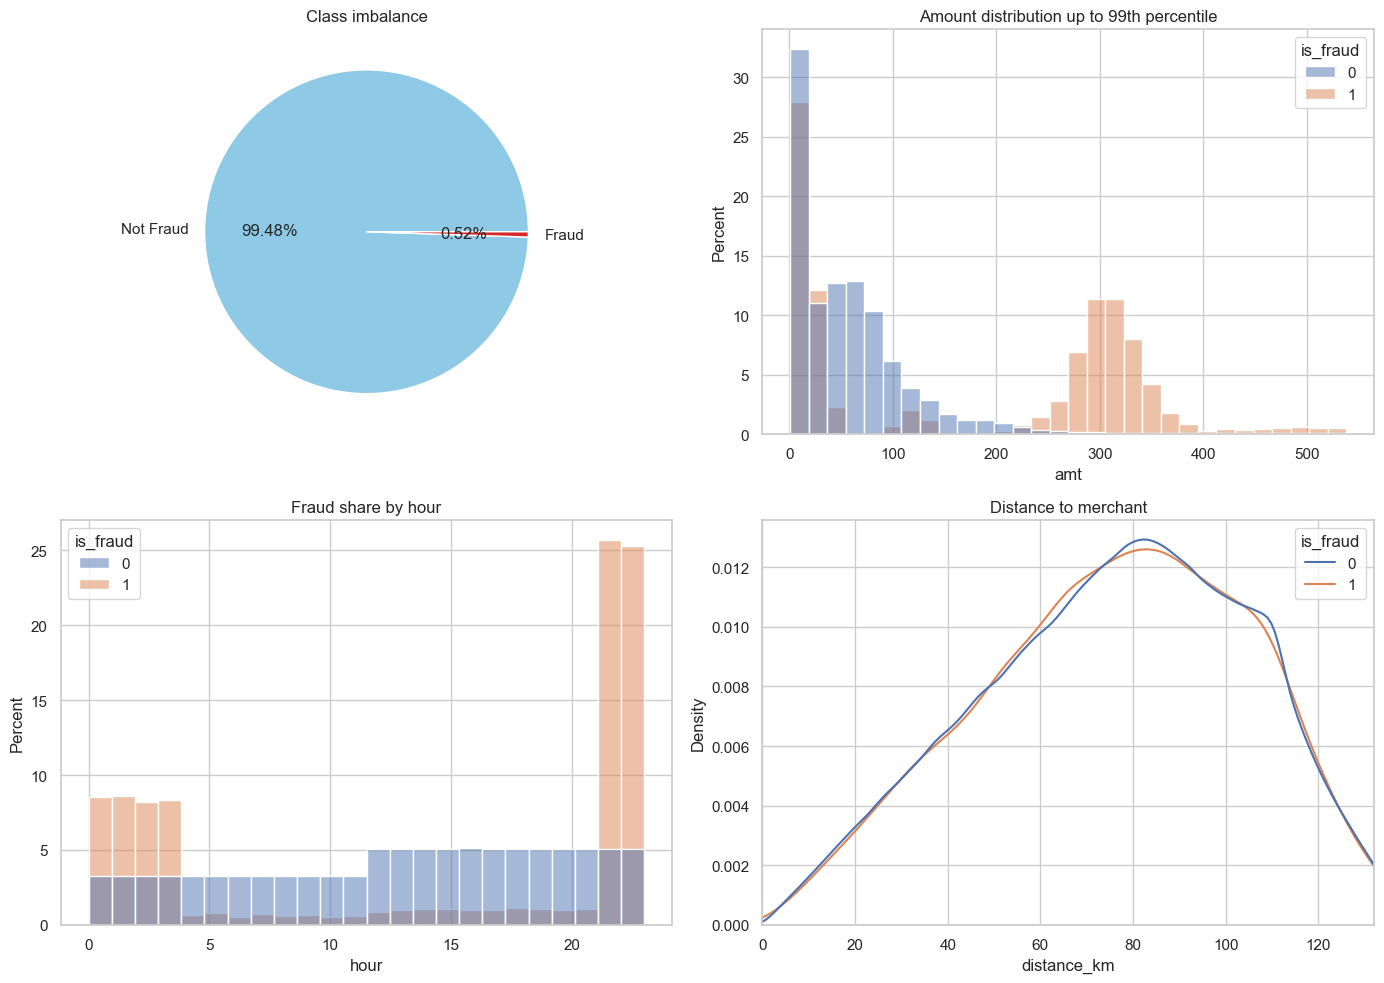

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fraud_counts = df["is_fraud"].value_counts().sort_index()
axes[0, 0].pie(fraud_counts, labels=["Not Fraud", "Fraud"], autopct="%1.2f%%", colors=["#8ecae6", "#d62828"])
axes[0, 0].set_title("Class imbalance")

sns.histplot(data=df[df["amt"] <= df["amt"].quantile(0.99)], x="amt", hue="is_fraud", bins=30, stat="percent", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Amount distribution up to 99th percentile")

sns.histplot(data=df, x="hour", hue="is_fraud", bins=24, stat="percent", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Fraud share by hour")

sns.kdeplot(data=df, x="distance_km", hue="is_fraud", common_norm=False, ax=axes[1, 1])
axes[1, 1].set_xlim(0, df["distance_km"].quantile(0.99))
axes[1, 1].set_title("Distance to merchant")

plt.tight_layout()

,total_transactions,fraud_rate,avg_amount
category,,,
shopping_net,139322,0.0159,86.9420
misc_net,90654,0.0130,80.1814
grocery_pos,176191,0.0126,116.6401
shopping_pos,166463,0.0063,78.9067
gas_transport,188029,0.0041,63.4773
misc_pos,114229,0.0028,62.6765
grocery_net,64878,0.0027,53.6885
travel,57956,0.0027,111.7712
personal_care,130085,0.0022,48.0479


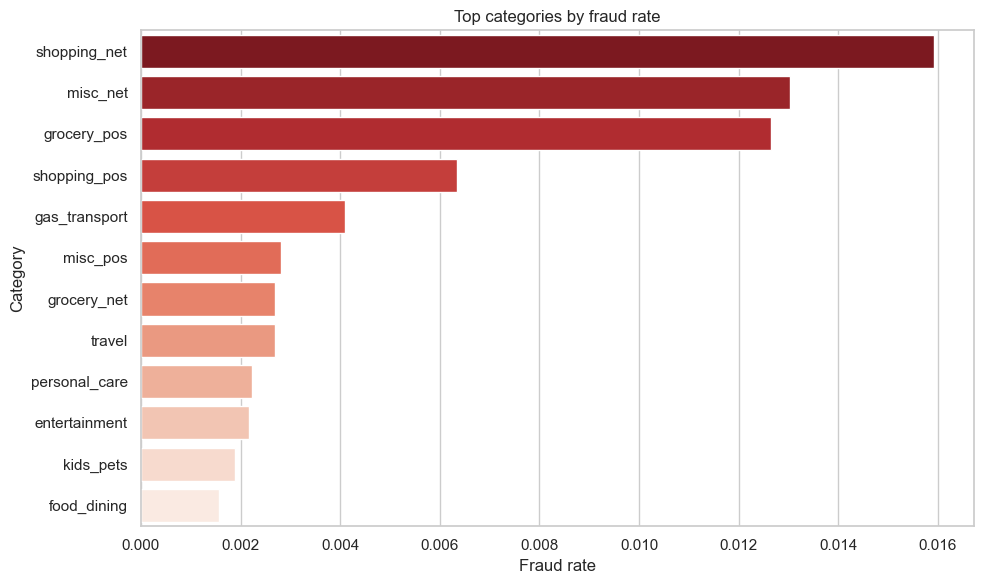

In [44]:
category_risk = (
    df.groupby("category")
      .agg(total_transactions=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"), avg_amount=("amt", "mean"))
      .sort_values("fraud_rate", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_risk.head(12).reset_index(), x="fraud_rate", y="category", palette="Reds_r")
plt.title("Top categories by fraud rate")
plt.xlabel("Fraud rate")
plt.ylabel("Category")
plt.tight_layout()

display(category_risk.head(12))

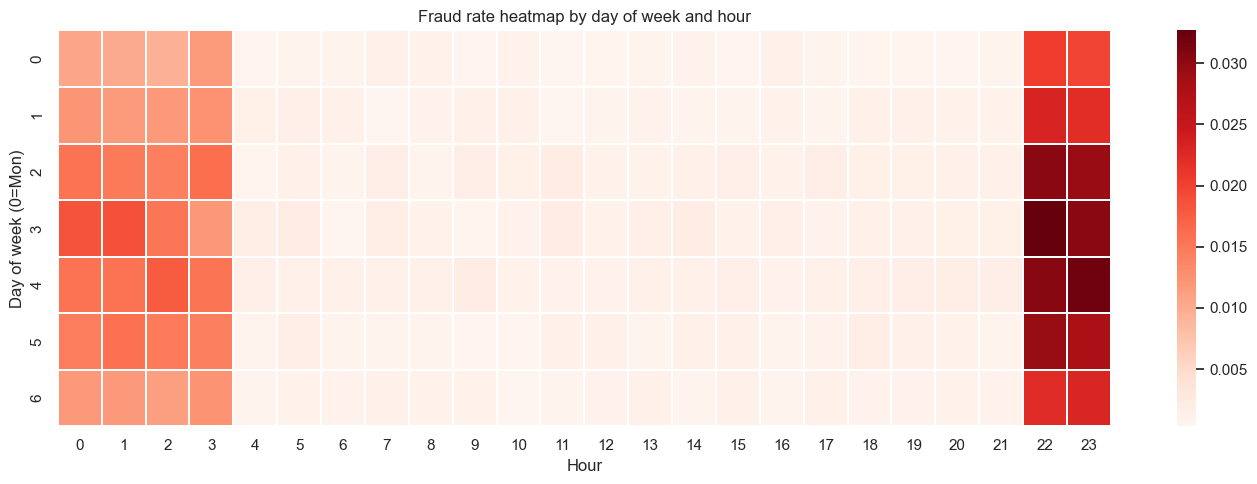

In [45]:
hour_day_heatmap = (
    df.pivot_table(index="day_of_week", columns="hour", values="is_fraud", aggfunc="mean")
      .sort_index()
)

plt.figure(figsize=(14, 5))
sns.heatmap(hour_day_heatmap, cmap="Reds", linewidths=0.2)
plt.title("Fraud rate heatmap by day of week and hour")
plt.xlabel("Hour")
plt.ylabel("Day of week (0=Mon)")
plt.tight_layout()

,total_transactions,fraud_rate,median_distance_km
amount_bucket,,,
0-10,480179,0.0014,78.2711
10-50,481050,0.0029,78.2861
50-100,556287,0.0001,78.1600
100-200,247605,0.0008,78.0597
200-500,65564,0.0401,78.3956
500-1000,16190,0.2137,77.8118
1000+,5519,0.2220,78.3828


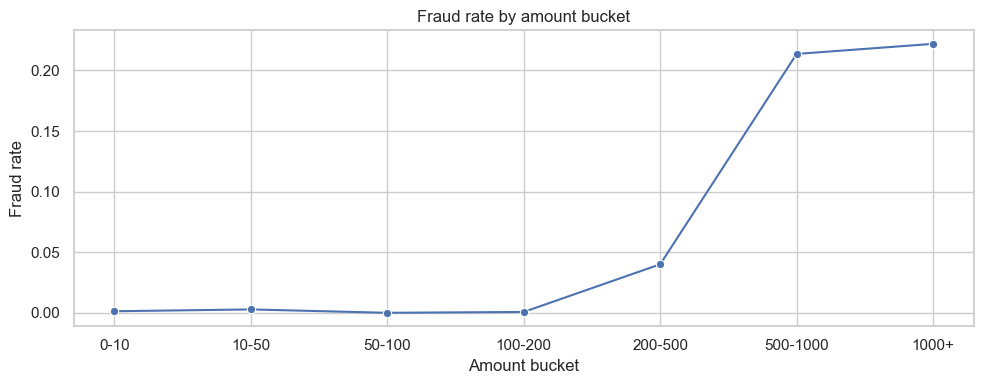

In [46]:
amount_bucket = pd.cut(
    df["amt"],
    bins=[0, 10, 50, 100, 200, 500, 1000, np.inf],
    labels=["0-10", "10-50", "50-100", "100-200", "200-500", "500-1000", "1000+"]
)

bucket_summary = (
    df.assign(amount_bucket=amount_bucket)
      .groupby("amount_bucket", observed=False)
      .agg(total_transactions=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"), median_distance_km=("distance_km", "median"))
)

display(bucket_summary)

plt.figure(figsize=(10, 4))
sns.lineplot(data=bucket_summary.reset_index(), x="amount_bucket", y="fraud_rate", marker="o")
plt.title("Fraud rate by amount bucket")
plt.xlabel("Amount bucket")
plt.ylabel("Fraud rate")
plt.tight_layout()